<a href="https://colab.research.google.com/github/adithyakp2004/ML-Lab-programs/blob/main/ML_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/adithyakp2004/ML-Lab-programs


Cloning into 'ML-Lab-programs'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 178 (delta 11), reused 0 (delta 0), pack-reused 148 (from 1)
Receiving objects: 100% (178/178), 65.84 KiB | 2.99 MiB/s, done.
Resolving deltas: 100% (78/78), done.


In [12]:
import pandas as pd

data = pd.read_csv("/content/ML-Lab-programs/dataset1.csv")

h = ['0', '0']

for _, row in data.iterrows():

    if row['Result'] == 'Yes':

        if h == ['0', '0']:
            h = [row['Weather'], row['Temp']]

        else:
            if h[0] != row['Weather']:
                h[0] = '?'

            if h[1] != row['Temp']:
                h[1] = '?'

print("Hypothesis:", h)

Hypothesis: ['Rain', '?']


In [14]:
import pandas as pd

data = pd.read_csv("/content/ML-Lab-programs/dataset1.csv")

features = data[['Weather', 'Temp']].values
labels = data['Result'].values

specific = features[labels == "Yes"][0]

for f in features[labels == "Yes"]:
    specific = [specific[i] if specific[i] == f[i] else "?"
                for i in range(len(f))]

print("Specific Hypothesis:", specific)

print("General Hypothesis:")
for f in features[labels == "No"]:
    print([specific[i] if f[i] != specific[i] else "?"
           for i in range(len(f))])

Specific Hypothesis: ['Rain', '?']
General Hypothesis:
['Rain', '?']
['Rain', '?']
['Rain', '?']


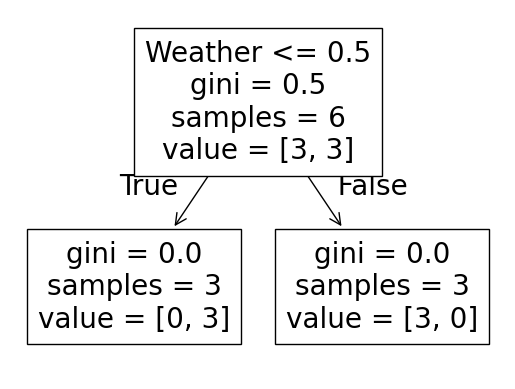

Prediction: Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [15]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

data = pd.read_csv("/content/ML-Lab-programs/dataset1.csv")

X = data[['Weather', 'Temp']].copy()
y = data['Result']

le = LabelEncoder()

X['Weather'] = le.fit_transform(X['Weather'])
X['Temp'] = le.fit_transform(X['Temp'])
y = le.fit_transform(y)

model = DecisionTreeClassifier()
model.fit(X, y)

plot_tree(model, feature_names=['Weather', 'Temp'])
plt.show()

result = model.predict([[0, 1]])
print("Prediction:", "Yes" if result[0] else "No")

In [ ]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

data = pd.read_csv("/content/ML-Lab-programs/dataset2.csv")

X = data[['Hours', 'Marks']]
y = data['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

result = model.predict([[4, 65]])
print("Prediction:", result[0])

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Prediction: Yes
Accuracy: 0.0
              precision    recall  f1-score   support

          No       0.00      0.00      0.00       2.0
         Yes       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. 

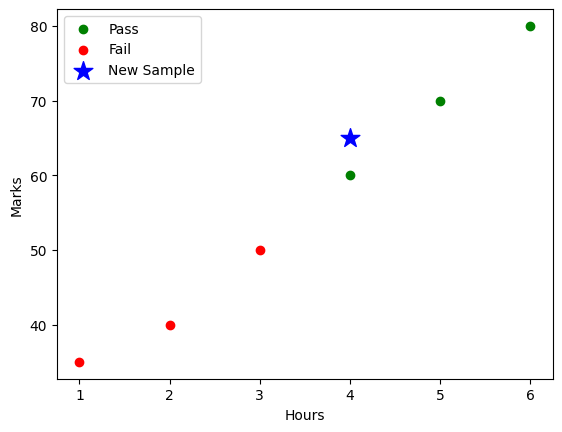

Prediction: Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

data = pd.read_csv("/content/ML-Lab-programs/dataset2.csv")

X = data[['Hours', 'Marks']]
y = data['Result']

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

passed = data[data['Result'] == 'Yes']
failed = data[data['Result'] == 'No']

plt.scatter(passed['Hours'], passed['Marks'],
            color='green', label='Pass')

plt.scatter(failed['Hours'], failed['Marks'],
            color='red', label='Fail')

plt.scatter(4, 65,
            marker='*', s=200,
            color='blue', label='New Sample')

plt.xlabel("Hours")
plt.ylabel("Marks")
plt.legend()
plt.show()

result = model.predict([[4, 65]])
print("Prediction:", result[0])

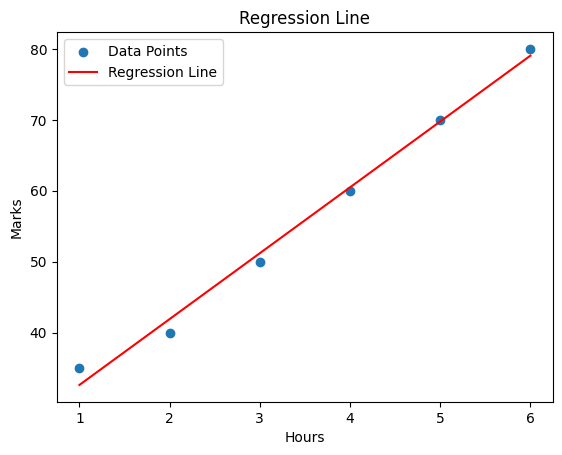

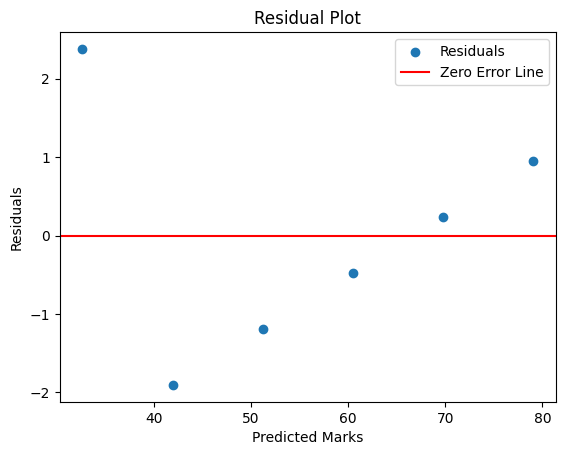

MAE = 1.190476190476191
MSE = 1.9841269841269857
RMSE = 1.4085904245475283
R2 Score = 0.9921722113502935


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

data = pd.read_csv("/content/ML-Lab-programs/dataset2.csv")

X = data[['Hours']]
y = data['Marks']

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

plt.scatter(X, y, label='Data Points')
plt.plot(X, pred, 'r', label='Regression Line')
plt.title("Regression Line")
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.legend()
plt.show()

residuals = y - pred

plt.scatter(pred, residuals, label='Residuals')
plt.axhline(y=0, color='r', label='Zero Error Line')
plt.title("Residual Plot")
plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.legend()
plt.show()

print("MAE =", mean_absolute_error(y, pred))
print("MSE =", mean_squared_error(y, pred))
print("RMSE =", np.sqrt(mean_squared_error(y, pred)))
print("R2 Score =", r2_score(y, pred))

In [19]:
import pandas as pd

data = {
    'Marks':[45,56,67,78,89,45,67,78,90,56]
}

df = pd.DataFrame(data)

print("DataFrame")
print(df)

print("\nSummary Statistics")
print(df.describe())

print("\nMean =", df['Marks'].mean())
print("Median =", df['Marks'].median())
print("Mode =", df['Marks'].mode()[0])
print("Variance =", df['Marks'].var())
print("Standard Deviation =", df['Marks'].std())

DataFrame
   Marks
0     45
1     56
2     67
3     78
4     89
5     45
6     67
7     78
8     90
9     56

Summary Statistics
           Marks
count  10.000000
mean   67.100000
std    16.549253
min    45.000000
25%    56.000000
50%    67.000000
75%    78.000000
max    90.000000

Mean = 67.1
Median = 67.0
Mode = 45
Variance = 273.87777777777785
Standard Deviation = 16.54925308821452


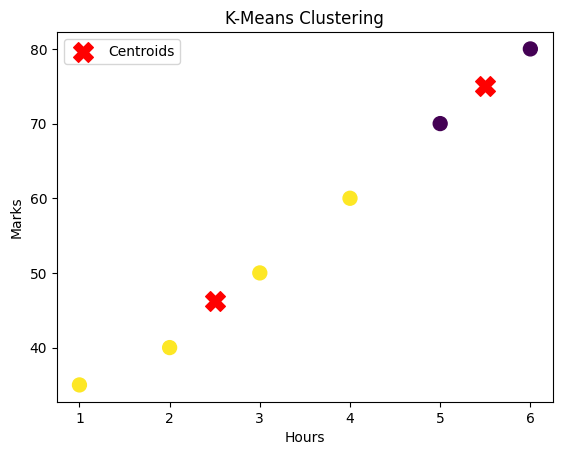

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = pd.read_csv("/content/ML-Lab-programs/dataset2.csv")

X = data[['Hours','Marks']]

model = KMeans(n_clusters=2)
model.fit(X)

labels = model.labels_
centroids = model.cluster_centers_

plt.scatter(X['Hours'], X['Marks'],
            c=labels, s=100)

plt.scatter(centroids[:,0], centroids[:,1],
            marker='X', color='red',
            s=200, label='Centroids')

plt.xlabel("Hours")
plt.ylabel("Marks")
plt.legend()
plt.title("K-Means Clustering")
plt.show()